In [1]:
import sys
sys.path.append('..')

import importlib

from util import config
from util.data_loader import DataLoader
import util.utilities as util

# Reload config first (paths live here)
importlib.reload(config)

# Reload utilities so they see the updated config
importlib.reload(util)

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt


In [ ]:
import numpy as np
import pandas as pd
from util import config

# -----------------------------
# Helpers (kept at module level)
# -----------------------------
KEYS = ["sub", "id", "date", "ses", "trial_id", "trial_type", "trial_type_day"]
NUMERIC_KEYS = ["sub", "ses", "trial_id", "trial_type_day"]
STRING_KEYS = ["id", "date", "trial_type"]
OVERWRITE_COLS = ["usable", "trial note"]

def _to_int_nullable(s: pd.Series) -> pd.Series:
    """Coerce to pandas nullable Int64 (keeps NA as <NA>)."""
    return pd.to_numeric(s, errors="coerce").astype("Int64")

def _ensure_keys(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure all key columns exist, with normalized dtypes."""
    df = df.copy()
    for k in KEYS:
        if k not in df.columns:
            df[k] = pd.NA
    for c in NUMERIC_KEYS:
        df[c] = _to_int_nullable(df[c])
    for c in STRING_KEYS:
        df[c] = df[c].astype("string")
    return df

def _key_index(df: pd.DataFrame) -> pd.MultiIndex:
    return pd.MultiIndex.from_frame(df[KEYS])

def _normalize_animal_info(animal_info: pd.DataFrame) -> pd.DataFrame:
    animal_info = animal_info.copy()
    if "sub" in animal_info.columns:
        animal_info["sub"] = _to_int_nullable(animal_info["sub"])
    if "id" in animal_info.columns:
        animal_info["id"] = animal_info["id"].astype("string")
    return animal_info

def _normalize_ephys(ephys_info: pd.DataFrame) -> pd.DataFrame:
    ephys = _ensure_keys(ephys_info)

    if "ephys_trial_id" not in ephys.columns:
        ephys["ephys_trial_id"] = pd.NA
    if "ephys_usable" not in ephys.columns:
        ephys["ephys_usable"] = pd.NA

    ephys["ephys_trial_id"] = _to_int_nullable(ephys["ephys_trial_id"])
    ephys["ephys_usable"] = _to_int_nullable(ephys["ephys_usable"])

    if "usable" in ephys.columns:
        ephys["usable"] = _to_int_nullable(ephys["usable"])
    if "trial note" in ephys.columns:
        ephys["trial note"] = ephys["trial note"].astype("string")
    return ephys

def _merge_ephys(meta: pd.DataFrame, ephys: pd.DataFrame) -> pd.DataFrame:
    bring = []
    if "ephys_trial_id" in ephys.columns:
        bring.append("ephys_trial_id")
    if "ephys_usable" in ephys.columns:
        bring.append("ephys_usable")

    overwrite_cols = []
    for c in OVERWRITE_COLS:
        if c in meta.columns and c in ephys.columns:
            overwrite_cols.append(c)
            bring.append(c)

    ephys_merge = ephys[KEYS + bring].copy()
    merged = meta.merge(ephys_merge, on=KEYS, how="left", suffixes=("", "_ephys"))

    for c in overwrite_cols:
        c_e = f"{c}_ephys"
        if c_e in merged.columns:
            use_e = merged[c_e].notna() & (merged[c_e] != merged[c])
            merged.loc[use_e, c] = merged.loc[use_e, c_e]
            merged = merged.drop(columns=[c_e])

    if "usable" in merged.columns:
        merged["usable"] = _to_int_nullable(merged["usable"])
    if "ephys_trial_id" in merged.columns:
        merged["ephys_trial_id"] = _to_int_nullable(merged["ephys_trial_id"])
    if "ephys_usable" in merged.columns:
        merged["ephys_usable"] = _to_int_nullable(merged["ephys_usable"])
    return merged

def _append_ephys_only(merged: pd.DataFrame, meta: pd.DataFrame, ephys: pd.DataFrame, animal_info: pd.DataFrame) -> pd.DataFrame:
    base_keys_idx = _key_index(meta.drop_duplicates(KEYS))
    ephys_keys_idx = _key_index(ephys.drop_duplicates(KEYS))
    is_new = ~ephys_keys_idx.isin(base_keys_idx)
    if not np.any(is_new):
        return merged

    ephys_only = ephys.loc[is_new].copy()
    ephys_only = ephys_only.drop_duplicates(subset=KEYS, keep="first")
    ephys_only = ephys_only.merge(animal_info, on=["sub", "id"], how="left", suffixes=("", "_animal"))

    for col in merged.columns:
        if col not in ephys_only.columns:
            ephys_only[col] = pd.NA
    for col in ephys_only.columns:
        if col not in merged.columns:
            merged[col] = pd.NA

    ephys_only = ephys_only[merged.columns]
    return pd.concat([merged, ephys_only], ignore_index=True)

def load_metadata(type: str = "combined") -> pd.DataFrame:
    """
    Read metadata files and optionally combine trials + animals + ephys.

    ephys merge rules:
      - merge on keys: ['sub','id','date','ses','trial_id','trial_type','trial_type_day']
      - add ephys_info columns: ephys_trial_id, ephys_usable
      - overwrite meta['usable'] and meta['trial note'] using ephys values when they differ (and ephys is non-null)
      - append ephys-only rows (keys present in ephys but not in meta)
    """
    animal_info = pd.read_csv(config.animal_info_path)
    trial_info = pd.read_csv(config.trial_info_path)
    ephys_info = pd.read_csv(config.ephys_info_path)

    if type == "animals":
        return animal_info
    if type == "trials":
        return trial_info
    if type == "ephys":
        return ephys_info
    if type != "combined":
        raise ValueError("type must be one of: 'combined', 'animals', 'trials', 'ephys'")

    trial_info_n = _ensure_keys(trial_info)
    animal_info_n = _normalize_animal_info(animal_info)
    meta = trial_info_n.merge(animal_info_n, on=["sub", "id"], how="left")

    if "usable" in meta.columns:
        meta["usable"] = _to_int_nullable(meta["usable"])
    if "trial note" in meta.columns:
        meta["trial note"] = meta["trial note"].astype("string")

    ephys = _normalize_ephys(ephys_info)
    merged = _merge_ephys(meta, ephys)
    merged = _append_ephys_only(merged, meta, ephys, animal_info_n)

    merged = merged.sort_values(by=KEYS, kind="mergesort").reset_index(drop=True)
    return merged

In [9]:
metadata = load_metadata("combined")
dl = DataLoader(metadata.iloc[1395])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

In [10]:
metadata

,sub,id,date,ses,trial_id,trial_type,trial_type_day,test_type,usable,trial_note,genotype,test_order,remapping,short_duration,LFP,animal_note,ephys_trial_id,ephys_usable
0,1,A,20241205,1,1,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN,<NA>,<NA>
1,1,A,20241205,1,2,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN,<NA>,<NA>
2,1,A,20241205,1,3,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN,<NA>,<NA>
3,1,A,20241205,1,4,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN,<NA>,<NA>
4,1,A,20241205,1,5,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5986,63,BR,20251223,8,5,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN,<NA>,<NA>
5987,63,BR,20251223,8,6,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN,<NA>,<NA>
5988,63,BR,20251223,8,7,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN,<NA>,<NA>
5989,63,BR,20251223,8,8,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN,<NA>,<NA>


In [12]:
meta_ephys = metadata[
    (metadata['id'].isin(['AM', 'AN','AO'])) ]

meta_ephys

,sub,id,date,ses,trial_id,trial_type,trial_type_day,test_type,usable,trial_note,genotype,test_order,remapping,short_duration,LFP,animal_note,ephys_trial_id,ephys_usable
1507,16,AM,20250725,1,1,H,1,NaN,1,NaN,ChR2,ef,1,0,1,"experiment repeated for this animal, first rou...",1,0
1508,16,AM,20250725,1,2,H,1,NaN,1,NaN,ChR2,ef,1,0,1,"experiment repeated for this animal, first rou...",2,0
1509,16,AM,20250725,1,3,H,1,NaN,1,NaN,ChR2,ef,1,0,1,"experiment repeated for this animal, first rou...",3,0
1510,16,AM,20250725,1,4,H,1,NaN,1,NaN,ChR2,ef,1,0,1,"experiment repeated for this animal, first rou...",4,0
1511,16,AM,20250725,1,5,H,1,NaN,1,NaN,ChR2,ef,1,0,1,"experiment repeated for this animal, first rou...",5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3147,18,AO,20251011,47,11,T,1,NaN,1,NaN,ChR2,fe,1,0,1,"experiment repeated for this animal, first rou...",19,1
3148,18,AO,20251012,48,0,B,1,NaN,1,NaN,ChR2,fe,1,0,1,"experiment repeated for this animal, first rou...",1,1
3149,18,AO,20251012,48,1,T,1,NaN,0,NaN,ChR2,fe,1,0,1,"experiment repeated for this animal, first rou...",2,0
3150,18,AO,20251012,48,2,B,1,NaN,1,NaN,ChR2,fe,1,0,1,"experiment repeated for this animal, first rou...",4,1


In [14]:
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[180])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

In [15]:
dl.id, dl.ses_dir

('C', 'ses-08_date-20241007')

Text(0.5, 1.0, 'Animal Trajectory with Well Locations')

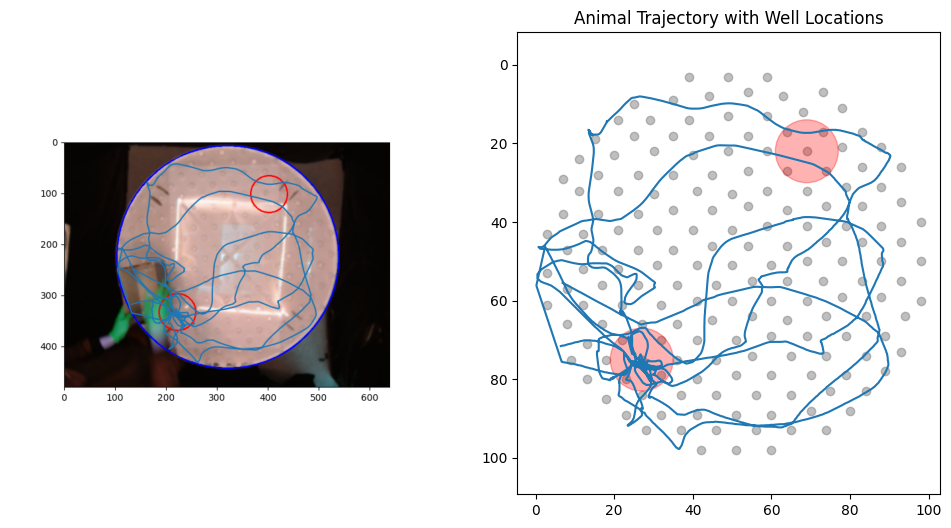

In [19]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(12,6), width_ratios=(1, 1))
axes[0].imshow(img)
axes[0].axis('off')

axes[1].plot(position['x'].values, position['y'].values)
axes[1].scatter(cheeseboardMap['x'].values, cheeseboardMap['y'].values, alpha=0.5, color='gray')
for i in range(len(triggerLoc)):
    x = triggerLoc['x'][i]
    y = triggerLoc['y'][i]
    circle = plt.Circle((x, y), 8, color='r', fill=True, linestyle='-', alpha=0.3)
    axes[1].add_artist(circle)

    # Equalize axis scales
axes[1].axis('equal')
# axes[1].axis('off')
# Flip the y-axis to match the coordinate system
axes[1].invert_yaxis()
axes[1].set_title('Animal Trajectory with Well Locations')